# XGBoost, Tuning and Model Selection

This notebook evaluates XGBoost and tunes the strongest models using only cross-validation on the training data.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from pcosense.data import load_clean_data
from pcosense.features import FEATURE_SETS
from pcosense.preprocessing import build_numeric_preprocessor

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

data = load_clean_data()

existing_results = pd.read_csv(
    PROJECT_ROOT / "reports" / "model_comparison.csv"
)

display(existing_results)

,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,full_clinical,random_forest,0.900,0.023,0.839,0.019,0.859,0.072,0.848,0.041,0.959,0.009,0.934,0.013
1,full_clinical,logistic_regression,0.883,0.027,0.792,0.060,0.882,0.027,0.833,0.034,0.945,0.008,0.918,0.005
2,full_clinical,decision_tree,0.832,0.028,0.703,0.049,0.854,0.053,0.769,0.032,0.912,0.022,0.823,0.042
3,screening_plus_labs,random_forest,0.819,0.022,0.706,0.037,0.769,0.047,0.735,0.032,0.891,0.025,0.807,0.064
4,screening,random_forest,0.828,0.025,0.717,0.040,0.786,0.041,0.749,0.036,0.889,0.028,0.812,0.072
5,screening,logistic_regression,0.823,0.026,0.702,0.048,0.808,0.031,0.750,0.028,0.880,0.029,0.814,0.071
6,screening_plus_labs,logistic_regression,0.810,0.034,0.687,0.056,0.780,0.053,0.729,0.042,0.869,0.035,0.803,0.064
7,screening,decision_tree,0.754,0.016,0.600,0.022,0.746,0.039,0.665,0.026,0.820,0.022,0.684,0.063
8,screening_plus_labs,decision_tree,0.760,0.040,0.613,0.056,0.740,0.078,0.668,0.051,0.814,0.028,0.640,0.039


In [2]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}


def create_xgboost_model():
    return Pipeline([
        (
            "preprocessor",
            build_numeric_preprocessor(scale=False)
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=1,
            )
        ),
    ])

In [3]:
xgboost_results = []

for feature_set, features in FEATURE_SETS.items():
    X = data[features]
    y = data["PCOS (Y/N)"]

    scores = cross_validate(
        create_xgboost_model(),
        X,
        y,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=1,
    )

    result = {
        "feature_set": feature_set,
        "model": "xgboost",
    }

    for metric in scoring:
        result[f"{metric}_mean"] = np.mean(
            scores[f"test_{metric}"]
        )
        result[f"{metric}_std"] = np.std(
            scores[f"test_{metric}"]
        )

    xgboost_results.append(result)

xgboost_df = pd.DataFrame(xgboost_results)

numeric_columns = xgboost_df.select_dtypes(
    include="number"
).columns

xgboost_df[numeric_columns] = (
    xgboost_df[numeric_columns].round(3)
)

display(xgboost_df)

,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,screening,xgboost,0.811,0.043,0.747,0.085,0.650,0.052,0.694,0.063,0.865,0.023,0.764,0.079
1,screening_plus_labs,xgboost,0.811,0.048,0.742,0.102,0.661,0.081,0.697,0.080,0.882,0.019,0.767,0.078
2,full_clinical,xgboost,0.917,0.023,0.893,0.029,0.847,0.053,0.869,0.037,0.958,0.009,0.932,0.013


In [4]:
combined_results = pd.concat(
    [existing_results, xgboost_df],
    ignore_index=True,
)

display(
    combined_results.sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,full_clinical,random_forest,0.900,0.023,0.839,0.019,0.859,0.072,0.848,0.041,0.959,0.009,0.934,0.013
11,full_clinical,xgboost,0.917,0.023,0.893,0.029,0.847,0.053,0.869,0.037,0.958,0.009,0.932,0.013
1,full_clinical,logistic_regression,0.883,0.027,0.792,0.060,0.882,0.027,0.833,0.034,0.945,0.008,0.918,0.005
2,full_clinical,decision_tree,0.832,0.028,0.703,0.049,0.854,0.053,0.769,0.032,0.912,0.022,0.823,0.042
3,screening_plus_labs,random_forest,0.819,0.022,0.706,0.037,0.769,0.047,0.735,0.032,0.891,0.025,0.807,0.064
4,screening,random_forest,0.828,0.025,0.717,0.040,0.786,0.041,0.749,0.036,0.889,0.028,0.812,0.072
10,screening_plus_labs,xgboost,0.811,0.048,0.742,0.102,0.661,0.081,0.697,0.080,0.882,0.019,0.767,0.078
5,screening,logistic_regression,0.823,0.026,0.702,0.048,0.808,0.031,0.750,0.028,0.880,0.029,0.814,0.071
6,screening_plus_labs,logistic_regression,0.810,0.034,0.687,0.056,0.780,0.053,0.729,0.042,0.869,0.035,0.803,0.064
9,screening,xgboost,0.811,0.043,0.747,0.085,0.650,0.052,0.694,0.063,0.865,0.023,0.764,0.079


## XGBoost findings

- XGBoost performs best by F1 score on the full clinical feature set.
- Random Forest has a nearly identical full-clinical ROC-AUC and PR-AUC.
- XGBoost performs worse than Logistic Regression and Random Forest on screening features.
- Therefore, Logistic Regression and Random Forest will be tuned for the screening application.
- Full-clinical XGBoost remains a comparison model because its performance is influenced by ultrasound features.

In [5]:
from pcosense.preprocessing import create_train_test_split

screening_features = FEATURE_SETS["screening"]

X_train, X_test, y_train, y_test = create_train_test_split(
    data=data,
    features=screening_features,
    test_size=0.2,
    random_state=42,
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (432, 18)
Testing: (109, 18)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

from pcosense.preprocessing import build_numeric_preprocessor

logistic_pipeline = Pipeline([
    (
        "preprocessor",
        build_numeric_preprocessor(scale=True)
    ),
    (
        "model",
        LogisticRegression(
            max_iter=3000,
            random_state=42,
        )
    ),
])

logistic_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear", "lbfgs"],
}

In [7]:
inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_grid,
    scoring="f1",
    cv=inner_cv,
    n_jobs=1,
    refit=True,
)

logistic_search.fit(X_train, y_train)

print("Best parameters:")
print(logistic_search.best_params_)

print(
    "Best training CV F1:",
    round(logistic_search.best_score_, 3)
)

Best parameters:
{'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best training CV F1: 0.754


In [8]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

best_logistic = logistic_search.best_estimator_

predictions = best_logistic.predict(X_test)
probabilities = best_logistic.predict_proba(X_test)[:, 1]

tuned_logistic_results = {
    "accuracy": accuracy_score(y_test, predictions),
    "precision": precision_score(y_test, predictions),
    "recall": recall_score(y_test, predictions),
    "f1": f1_score(y_test, predictions),
    "roc_auc": roc_auc_score(y_test, probabilities),
    "pr_auc": average_precision_score(
        y_test, probabilities
    ),
}

display(
    pd.Series(tuned_logistic_results).round(3)
)

accuracy     0.853
precision    0.778
recall       0.778
f1           0.778
roc_auc      0.885
pr_auc       0.812
dtype: float64

## Tuned Logistic Regression

The selected model uses stronger regularisation (`C = 0.01`) without automatic class weighting. It achieves a test F1 score of 0.778 and ROC-AUC of 0.885.

The improvement is modest, suggesting that the original Logistic Regression was already a strong baseline.

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        build_numeric_preprocessor(scale=False)
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42,
            n_jobs=1,
        )
    ),
])

In [10]:
random_forest_parameters = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [None, 4, 6, 8, 10],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 3, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
    "model__class_weight": [
        None,
        "balanced",
        "balanced_subsample",
    ],
}

In [11]:
random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_parameters,
    n_iter=20,
    scoring="f1",
    cv=inner_cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

random_forest_search.fit(X_train, y_train)

print("Best parameters:")
print(random_forest_search.best_params_)

print(
    "Best training CV F1:",
    round(random_forest_search.best_score_, 3)
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'model__n_estimators': 700, 'model__min_samples_split': 5, 'model__min_samples_leaf': 3, 'model__max_features': 'log2', 'model__max_depth': 6, 'model__class_weight': 'balanced_subsample'}
Best training CV F1: 0.769


In [12]:
best_random_forest = (
    random_forest_search.best_estimator_
)

rf_predictions = best_random_forest.predict(X_test)
rf_probabilities = (
    best_random_forest.predict_proba(X_test)[:, 1]
)

tuned_rf_results = {
    "accuracy": accuracy_score(y_test, rf_predictions),
    "precision": precision_score(y_test, rf_predictions),
    "recall": recall_score(y_test, rf_predictions),
    "f1": f1_score(y_test, rf_predictions),
    "roc_auc": roc_auc_score(
        y_test, rf_probabilities
    ),
    "pr_auc": average_precision_score(
        y_test, rf_probabilities
    ),
}

tuned_comparison = pd.DataFrame([
    {
        "model": "logistic_regression",
        **tuned_logistic_results,
    },
    {
        "model": "random_forest",
        **tuned_rf_results,
    },
])

numeric_columns = tuned_comparison.select_dtypes(
    include="number"
).columns

tuned_comparison[numeric_columns] = (
    tuned_comparison[numeric_columns].round(3)
)

display(tuned_comparison)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,0.853,0.778,0.778,0.778,0.885,0.812
1,random_forest,0.862,0.800,0.778,0.789,0.889,0.808


## Tuned screening-model comparison

Random Forest achieves the highest accuracy, F1 and ROC-AUC. Logistic Regression has the same recall and slightly higher PR-AUC.

The performance difference is small, so calibration and explainability will also influence final model selection.

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_estimator(
    best_logistic,
    X_test,
    y_test,
    display_labels=["No PCOS", "PCOS"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Tuned Logistic Regression")

ConfusionMatrixDisplay.from_estimator(
    best_random_forest,
    X_test,
    y_test,
    display_labels=["No PCOS", "PCOS"],
    cmap="Greens",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Tuned Random Forest")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [14]:
import matplotlib.pyplot as plt

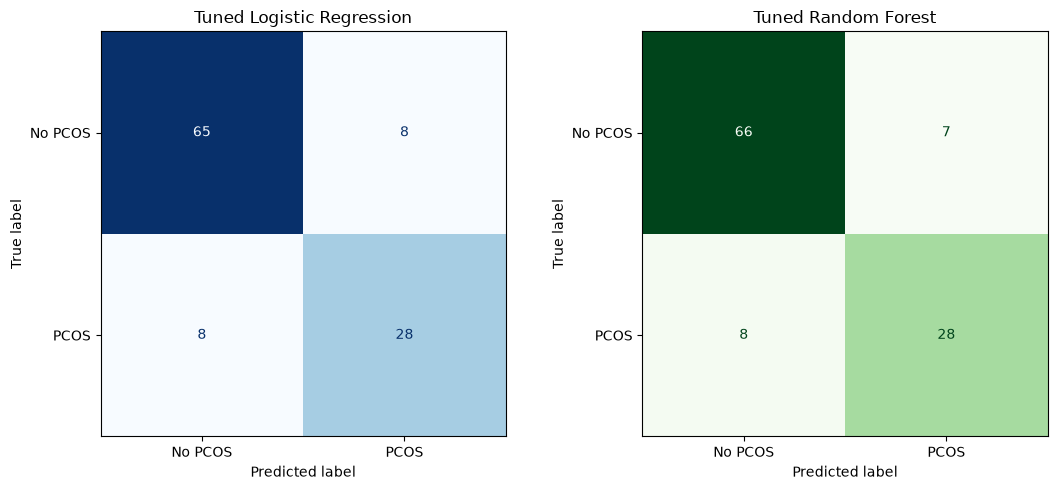

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_estimator(
    best_logistic,
    X_test,
    y_test,
    display_labels=["No PCOS", "PCOS"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Tuned Logistic Regression")

ConfusionMatrixDisplay.from_estimator(
    best_random_forest,
    X_test,
    y_test,
    display_labels=["No PCOS", "PCOS"],
    cmap="Greens",
    colorbar=False,
    ax=axes[1],
)
axes[1].set_title("Tuned Random Forest")

plt.tight_layout()
plt.show()

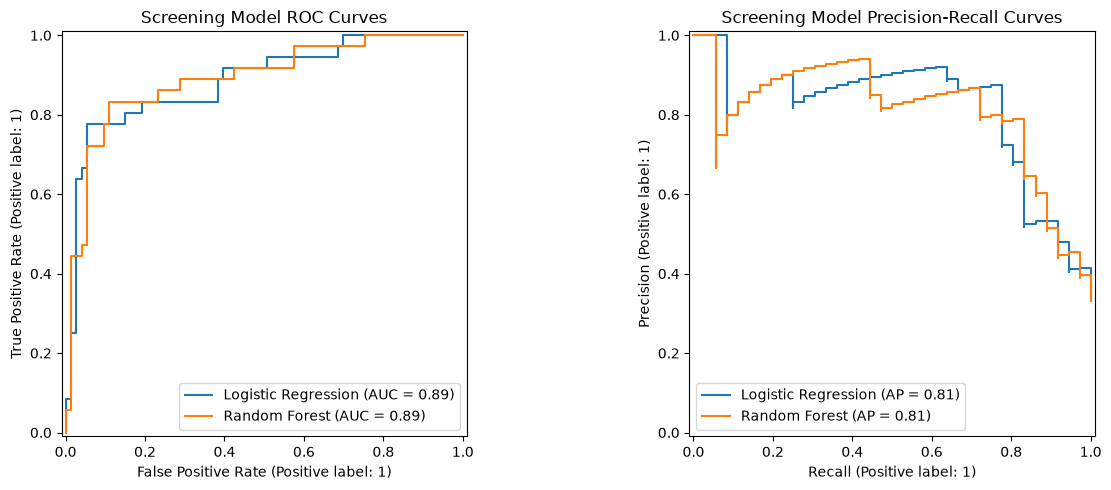

In [16]:
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for model, name in [
    (best_logistic, "Logistic Regression"),
    (best_random_forest, "Random Forest"),
]:
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=axes[0],
    )

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=axes[1],
    )

axes[0].set_title("Screening Model ROC Curves")
axes[1].set_title("Screening Model Precision-Recall Curves")

plt.tight_layout()
plt.show()

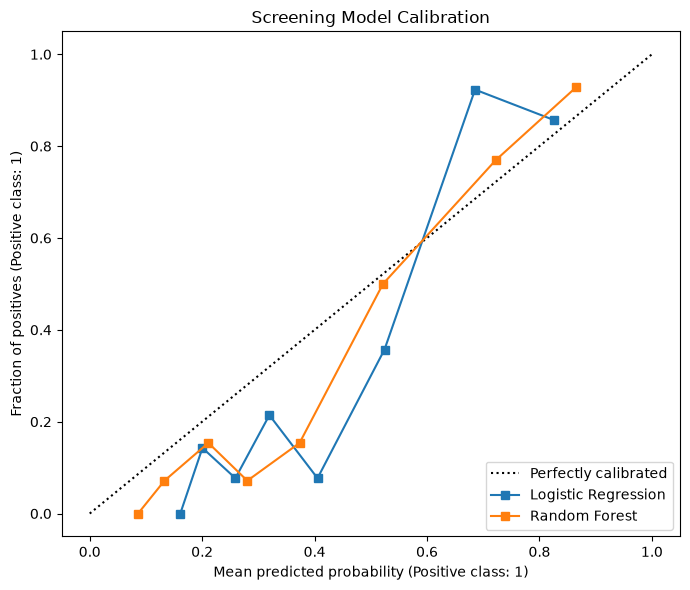

Logistic Brier score: 0.136
Random Forest Brier score: 0.125


In [17]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

logistic_probabilities = best_logistic.predict_proba(
    X_test
)[:, 1]

random_forest_probabilities = (
    best_random_forest.predict_proba(X_test)[:, 1]
)

fig, axis = plt.subplots(figsize=(7, 6))

for model_probabilities, name in [
    (logistic_probabilities, "Logistic Regression"),
    (random_forest_probabilities, "Random Forest"),
]:
    CalibrationDisplay.from_predictions(
        y_test,
        model_probabilities,
        n_bins=8,
        strategy="quantile",
        name=name,
        ax=axis,
    )

axis.set_title("Screening Model Calibration")
plt.tight_layout()
plt.show()

print(
    "Logistic Brier score:",
    round(
        brier_score_loss(
            y_test,
            logistic_probabilities
        ),
        3
    )
)

print(
    "Random Forest Brier score:",
    round(
        brier_score_loss(
            y_test,
            random_forest_probabilities
        ),
        3
    )
)

In [18]:
RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tuned_screening_comparison.csv"
)

tuned_comparison.to_csv(RESULTS_PATH, index=False)

print("Saved to:", RESULTS_PATH)

Saved to: c:\Users\Shreya Rathore\OneDrive\Desktop\PCOSense\reports\tuned_screening_comparison.csv


## Primary screening-model selection

The tuned Random Forest is selected as the primary screening model.

It achieves slightly better accuracy, precision, F1, ROC-AUC and probability calibration than the tuned Logistic Regression while maintaining the same recall.

The performance difference is small, so Logistic Regression remains the interpretable benchmark. Neither model should be treated as a diagnostic system, and external validation would be required before any clinical use.

In [19]:
selected_model = best_random_forest
selected_feature_set = "screening"
selected_features = FEATURE_SETS[selected_feature_set]

print("Selected model: Tuned Random Forest")
print("Feature set:", selected_feature_set)
print("Number of features:", len(selected_features))

Selected model: Tuned Random Forest
Feature set: screening
Number of features: 18


In [20]:
combined_results.to_csv(
    PROJECT_ROOT / "reports" / "model_comparison.csv",
    index=False,
)

print("Updated reports/model_comparison.csv")

Updated reports/model_comparison.csv


In [21]:
final_screening_comparison = tuned_comparison.copy()

final_screening_comparison["brier_score"] = [
    brier_score_loss(
        y_test,
        logistic_probabilities
    ),
    brier_score_loss(
        y_test,
        random_forest_probabilities
    ),
]

final_screening_comparison["selected"] = [
    False,
    True,
]

numeric_columns = final_screening_comparison.select_dtypes(
    include="number"
).columns

final_screening_comparison[numeric_columns] = (
    final_screening_comparison[numeric_columns].round(3)
)

final_screening_comparison.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tuned_screening_comparison.csv",
    index=False,
)

display(final_screening_comparison)

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,selected
0,logistic_regression,0.853,0.778,0.778,0.778,0.885,0.812,0.136,False
1,random_forest,0.862,0.800,0.778,0.789,0.889,0.808,0.125,True
